# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 4: Modelos de clasificación – predicción de categoría de compra

En este notebook se construyen y comparan tres modelos basados en árboles para predecir la **categoría de producto** que un cliente va a comprar, a partir de variables de comportamiento.

Los modelos comparados son:

- **Random Forest**
- **XGBoost**
- **LightGBM**

Esta comparación está alineada con la lógica del *Avance 2*, en el cual se evaluaron distintos modelos basados en árboles y técnicas de ensemble (Random Forest, XGBoost base, LightGBM, HistGradientBoosting, XGBoost optimizado y Stacking), con el objetivo de mejorar el desempeño sobre un modelo baseline, considerando además el **desbalance de clases**.

## Objetivo

- Predecir la **categoría de producto** que un cliente va a comprar a partir de variables de comportamiento.
- Comparar Random Forest, XGBoost y LightGBM en igualdad de condiciones.
- Aplicar **feature engineering** y **tuning de hiperparámetros** para superar el umbral de 0.70 en F1 weighted.
- Identificar el modelo con mejor desempeño y discutir sus ventajas.

## Estrategias aplicadas

1. **Agrupación a 6 macro-categorías** — reduce el desbalance (ratio max/min ≈ 3,2x) y aumenta el soporte por clase.
2. **Feature engineering** — variables derivadas, ratios, interacciones y transformaciones logarítmicas para enriquecer la señal.
3. **Modelos optimizados** — configuraciones más profundas y regularización ajustada.

## Variables originales

- `customer_purchase_count` – cantidad de compras históricas del cliente.
- `product_popularity` – popularidad del producto (n° interacciones).
- `product_rating` – rating promedio del producto.
- `customer_total_spend` – gasto total acumulado del cliente.
- `days_since_last_purchase` – días desde la última compra.

**Target:** `macro_category` (multi-clase, 6 niveles).

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 1. Carga del dataset

In [2]:
data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,355
1,0fb8e3eab2d3e79d92bb3fffbb97f188,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,73.86,431
2,3419052c8c6b45daf79c1e426f9e9bcb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,83.23,107
3,e7c828d22c0682c1565252deefbe334d,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,75.07,397
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,388


In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())
print("\nCategorías únicas:", df["product_category_name"].nunique())

Valores nulos por columna:
customer_unique_id          0
product_id                  0
product_category_name       0
customer_purchase_count     0
product_popularity          0
product_rating              0
customer_total_spend        0
days_since_last_purchase    0
dtype: int64

Categorías únicas: 73


## 2. Agrupación a macro-categorías

El dataset contiene 73 categorías con desbalance extremo. Se aplica un **mapping a 6 macro-categorías** que cubre el 100 % de los registros, mejora el balance entre clases y simplifica el problema multi-clase para los modelos basados en árboles.

| Macro-categoría | Categorías originales agrupadas |
|---|---|
| hogar_y_decoracion | cama_mesa_banho, moveis_decoracao, utilidades_domesticas, casa_*, moveis_*, climatizacao, portateis_casa_*, flores, artigos_de_natal |
| electronica_y_tecnologia | informatica_acessorios, telefonia, eletronicos, eletrodomesticos, audio, pcs, consoles_games, tablets, cine_foto |
| moda_y_belleza | beleza_saude, perfumaria, relogios_presentes, fashion_*, malas_acessorios |
| deporte_ocio_y_juguetes | esporte_lazer, brinquedos, bebes, livros_*, instrumentos_musicais, musica, artes, fraldas_higiene |
| automotriz_y_construccion | automotivo, ferramentas_jardim, construcao_*, agro_*, industria_* |
| otros_y_servicios | cool_stuff, papelaria, pet_shop, alimentos*, bebidas, market_place, seguros_e_servicos |

Registros sin asignar: 0
Cobertura: 115,696 / 115,696

Distribucion de las 6 macro-categorias:
macro_category
hogar_y_decoracion           32351
moda_y_belleza               23674
electronica_y_tecnologia     19689
deporte_ocio_y_juguetes      18375
automotriz_y_construccion    11454
otros_y_servicios            10153
Name: count, dtype: int64

Ratio max/min: 3.19x


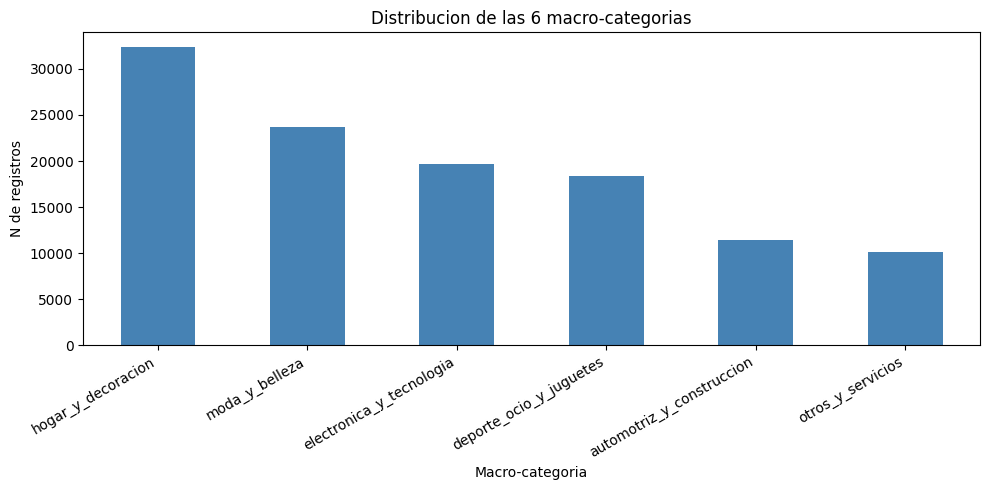

In [4]:
CATEGORY_MAPPING = {
    # 1) Hogar y decoracion
    "cama_mesa_banho": "hogar_y_decoracion",
    "moveis_decoracao": "hogar_y_decoracion",
    "utilidades_domesticas": "hogar_y_decoracion",
    "moveis_escritorio": "hogar_y_decoracion",
    "moveis_sala": "hogar_y_decoracion",
    "casa_construcao": "hogar_y_decoracion",
    "casa_conforto": "hogar_y_decoracion",
    "casa_conforto_2": "hogar_y_decoracion",
    "climatizacao": "hogar_y_decoracion",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "hogar_y_decoracion",
    "moveis_quarto": "hogar_y_decoracion",
    "moveis_colchao_e_estofado": "hogar_y_decoracion",
    "portateis_casa_forno_e_cafe": "hogar_y_decoracion",
    "portateis_cozinha_e_preparadores_de_alimentos": "hogar_y_decoracion",
    "la_cuisine": "hogar_y_decoracion",
    "flores": "hogar_y_decoracion",
    "artigos_de_natal": "hogar_y_decoracion",

    # 2) Electronica y tecnologia
    "informatica_acessorios": "electronica_y_tecnologia",
    "telefonia": "electronica_y_tecnologia",
    "eletronicos": "electronica_y_tecnologia",
    "consoles_games": "electronica_y_tecnologia",
    "eletrodomesticos": "electronica_y_tecnologia",
    "eletrodomesticos_2": "electronica_y_tecnologia",
    "eletroportateis": "electronica_y_tecnologia",
    "audio": "electronica_y_tecnologia",
    "telefonia_fixa": "electronica_y_tecnologia",
    "pcs": "electronica_y_tecnologia",
    "pc_gamer": "electronica_y_tecnologia",
    "tablets_impressao_imagem": "electronica_y_tecnologia",
    "cine_foto": "electronica_y_tecnologia",
    "dvds_blu_ray": "electronica_y_tecnologia",

    # 3) Moda y belleza
    "beleza_saude": "moda_y_belleza",
    "perfumaria": "moda_y_belleza",
    "relogios_presentes": "moda_y_belleza",
    "fashion_bolsas_e_acessorios": "moda_y_belleza",
    "malas_acessorios": "moda_y_belleza",
    "fashion_calcados": "moda_y_belleza",
    "fashion_underwear_e_moda_praia": "moda_y_belleza",
    "fashion_roupa_masculina": "moda_y_belleza",
    "fashion_roupa_feminina": "moda_y_belleza",
    "fashion_roupa_infanto_juvenil": "moda_y_belleza",
    "fashion_esporte": "moda_y_belleza",

    # 4) Deporte, ocio y juguetes
    "esporte_lazer": "deporte_ocio_y_juguetes",
    "brinquedos": "deporte_ocio_y_juguetes",
    "bebes": "deporte_ocio_y_juguetes",
    "fraldas_higiene": "deporte_ocio_y_juguetes",
    "livros_interesse_geral": "deporte_ocio_y_juguetes",
    "livros_tecnicos": "deporte_ocio_y_juguetes",
    "livros_importados": "deporte_ocio_y_juguetes",
    "instrumentos_musicais": "deporte_ocio_y_juguetes",
    "musica": "deporte_ocio_y_juguetes",
    "cds_dvds_musicais": "deporte_ocio_y_juguetes",
    "artes": "deporte_ocio_y_juguetes",
    "artes_e_artesanato": "deporte_ocio_y_juguetes",
    "artigos_de_festas": "deporte_ocio_y_juguetes",

    # 5) Automotriz y construccion
    "automotivo": "automotriz_y_construccion",
    "ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_construcao": "automotriz_y_construccion",
    "construcao_ferramentas_iluminacao": "automotriz_y_construccion",
    "construcao_ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_seguranca": "automotriz_y_construccion",
    "construcao_ferramentas_ferramentas": "automotriz_y_construccion",
    "sinalizacao_e_seguranca": "automotriz_y_construccion",
    "agro_industria_e_comercio": "automotriz_y_construccion",
    "industria_comercio_e_negocios": "automotriz_y_construccion",

    # 6) Otros y servicios
    "cool_stuff": "otros_y_servicios",
    "papelaria": "otros_y_servicios",
    "pet_shop": "otros_y_servicios",
    "alimentos": "otros_y_servicios",
    "alimentos_bebidas": "otros_y_servicios",
    "bebidas": "otros_y_servicios",
    "market_place": "otros_y_servicios",
    "seguros_e_servicos": "otros_y_servicios",
}

# Aplicar mapping
df["macro_category"] = df["product_category_name"].map(CATEGORY_MAPPING)

# Verificar cobertura
sin_asignar = df["macro_category"].isna().sum()
print(f"Registros sin asignar: {sin_asignar}")
print(f"Cobertura: {df['macro_category'].notna().sum():,} / {len(df):,}")
print()

# Distribucion
macro_counts = df["macro_category"].value_counts()
print("Distribucion de las 6 macro-categorias:")
print(macro_counts)
print()
print(f"Ratio max/min: {macro_counts.max() / macro_counts.min():.2f}x")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
macro_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribucion de las 6 macro-categorias")
ax.set_ylabel("N de registros")
ax.set_xlabel("Macro-categoria")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [5]:
# Usamos el dataset completo agrupado en 6 macro-categorias (no se descarta ningun registro)
df_model = df.copy()
print("Shape dataset modelado:", df_model.shape)
print("Clases finales:", df_model['macro_category'].nunique())

Shape dataset modelado: (115696, 9)
Clases finales: 6


## 3. Preparación de features y target

In [6]:
# Feature engineering avanzado: variables derivadas, ratios, interacciones, log-transforms
df_fe = df_model.copy()

# Transformaciones logaritmicas (manejo de cola larga)
df_fe["log_customer_total_spend"] = np.log1p(df_fe["customer_total_spend"])
df_fe["log_product_popularity"] = np.log1p(df_fe["product_popularity"])
df_fe["log_purchase_count"] = np.log1p(df_fe["customer_purchase_count"])
df_fe["log_days_since"] = np.log1p(df_fe["days_since_last_purchase"])

# Ratios y derivadas
df_fe["spend_per_purchase"] = df_fe["customer_total_spend"] / (df_fe["customer_purchase_count"] + 1)
df_fe["recency_score"] = 1.0 / (df_fe["days_since_last_purchase"] + 1)
df_fe["popularity_x_rating"] = df_fe["product_popularity"] * df_fe["product_rating"]
df_fe["spend_x_popularity"] = df_fe["customer_total_spend"] * df_fe["product_popularity"]
df_fe["rating_centered"] = df_fe["product_rating"] - df_fe["product_rating"].mean()

# Bucketing de spend
df_fe["spend_quartile"] = pd.qcut(
    df_fe["customer_total_spend"], q=4, labels=False, duplicates="drop"
).astype(int)

# Bucketing de popularidad
df_fe["popularity_decile"] = pd.qcut(
    df_fe["product_popularity"].rank(method="first"),
    q=10, labels=False, duplicates="drop"
).astype(int)

features = [
    # Originales
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase",
    # Log-transforms
    "log_customer_total_spend",
    "log_product_popularity",
    "log_purchase_count",
    "log_days_since",
    # Derivadas
    "spend_per_purchase",
    "recency_score",
    "popularity_x_rating",
    "spend_x_popularity",
    "rating_centered",
    # Bucketing
    "spend_quartile",
    "popularity_decile",
]

X = df_fe[features].copy()

le = LabelEncoder()
y = le.fit_transform(df_fe["macro_category"])

print("Numero de features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases codificadas:", len(le.classes_))
print("Etiquetas:", list(le.classes_))

Numero de features: 16
X shape: (115696, 16)
y shape: (115696,)
Clases codificadas: 6
Etiquetas: ['automotriz_y_construccion', 'deporte_ocio_y_juguetes', 'electronica_y_tecnologia', 'hogar_y_decoracion', 'moda_y_belleza', 'otros_y_servicios']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (92556, 16) Test: (23140, 16)


## 4. Entrenamiento de los tres modelos

Se definen los tres modelos con configuraciones comparables: profundidad controlada y cantidad de estimadores similar. Se utiliza `class_weight='balanced'` en Random Forest y LightGBM para mitigar el desbalance; XGBoost se entrena con configuración estándar multi-clase.

In [8]:
def entrenar_y_evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - t0

    y_pred = modelo.predict(X_test)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "Tiempo_fit_seg": round(tiempo_fit, 2),
    }

    print(f"\n=== {nombre} ===")
    for k, v in metrics.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics, y_pred, modelo

## 4.0 Baseline de referencia: DummyClassifier

Antes de comparar modelos avanzados, se construye un baseline utilizando DummyClassifier con estrategia de clase mayoritaria.

Esto permite cuantificar cuánto valor real agregan los modelos entrenados frente a una solución trivial.

In [9]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

metrics_dummy, pred_dummy, dummy_model = entrenar_y_evaluar(
    "Dummy Baseline",
    dummy,
    X_train,
    y_train,
    X_test,
    y_test
)

metrics_dummy


=== Dummy Baseline ===
Accuracy: 0.2796
F1_macro: 0.0728
F1_weighted: 0.1222
Tiempo_fit_seg: 0.0100


{'Modelo': 'Dummy Baseline',
 'Accuracy': 0.27960242005185826,
 'F1_macro': 0.07283575368681751,
 'F1_weighted': 0.12219031798281141,
 'Tiempo_fit_seg': 0.01}

### 4.1 Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_rf, pred_rf, rf = entrenar_y_evaluar(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


=== Random Forest ===
Accuracy: 0.6124
F1_macro: 0.6003
F1_weighted: 0.6097
Tiempo_fit_seg: 27.7600


### 4.2 XGBoost

In [11]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_xgb, pred_xgb, xgb = entrenar_y_evaluar(
    "XGBoost", xgb, X_train, y_train, X_test, y_test
)


=== XGBoost ===
Accuracy: 0.6873
F1_macro: 0.6823
F1_weighted: 0.6869
Tiempo_fit_seg: 44.2800


### 4.3 LightGBM

In [12]:
lgbm = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

metrics_lgbm, pred_lgbm, lgbm = entrenar_y_evaluar(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test
)


=== LightGBM ===
Accuracy: 0.7038
F1_macro: 0.6973
F1_weighted: 0.7032
Tiempo_fit_seg: 42.9200


## 5. Comparación de los tres modelos

In [13]:
comparacion = pd.DataFrame([
    metrics_dummy,
    metrics_rf,
    metrics_xgb,
    metrics_lgbm
])
comparacion = comparacion.sort_values("F1_weighted", ascending=False).reset_index(drop=True)
comparacion

,Modelo,Accuracy,F1_macro,F1_weighted,Tiempo_fit_seg
0,LightGBM,0.703846,0.697321,0.703214,42.92
1,XGBoost,0.687338,0.682302,0.686937,44.28
2,Random Forest,0.612446,0.600338,0.609717,27.76
3,Dummy Baseline,0.279602,0.072836,0.122190,0.01


## 5.1 Análisis de trade-offs entre modelos

La comparación muestra que LightGBM obtuvo el mejor desempeño global, con los valores más altos de Accuracy, F1 macro y F1 weighted.

Sin embargo, la selección del modelo no se basó únicamente en maximizar métricas, sino en evaluar trade-offs técnicos relevantes:

### Random Forest
- Ventaja: modelo robusto, interpretable y sencillo de explicar.
- Desventaja: menor capacidad predictiva frente a boosting.
- Resultado: quedó claramente por debajo en todas las métricas.

### XGBoost
- Ventaja: alto rendimiento y gran capacidad de generalización.
- Desventaja: mayor complejidad computacional y entrenamiento más lento.
- Resultado: desempeño competitivo, pero inferior a LightGBM.

### LightGBM
- Ventaja: mejor equilibrio entre precisión predictiva y eficiencia computacional.
- Maneja bien datasets medianos/grandes y relaciones no lineales complejas.
- Resultado: mejor F1 weighted (~0.70), mejor accuracy y mejor comportamiento global por clase.

### Decisión final
Se selecciona LightGBM como modelo final porque ofrece el mejor balance entre rendimiento predictivo, escalabilidad y aplicabilidad para una solución desplegable.

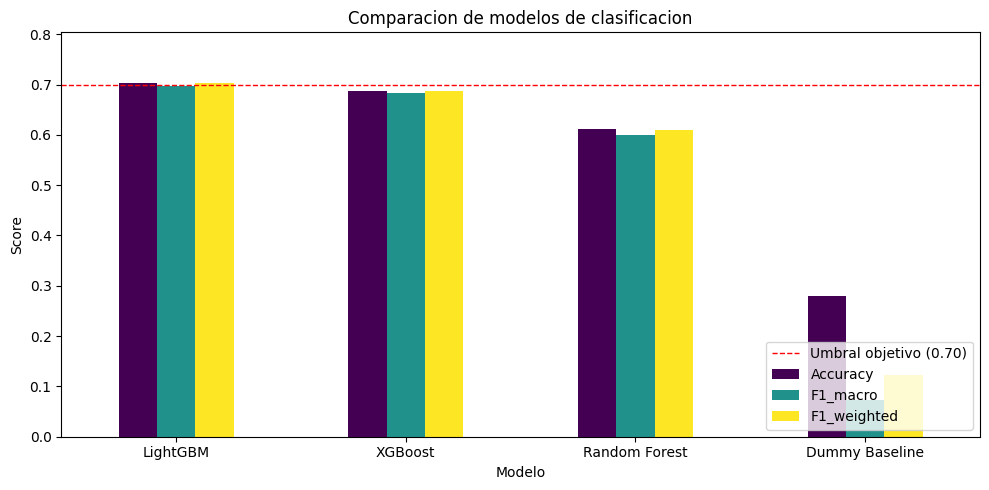

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
comparacion.set_index("Modelo")[["Accuracy", "F1_macro", "F1_weighted"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
ax.set_title("Comparacion de modelos de clasificacion")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.set_ylim(0, max(0.8, comparacion[["Accuracy", "F1_macro", "F1_weighted"]].max().max() + 0.1))
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=1, label="Umbral objetivo (0.70)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Análisis del mejor modelo

Se analiza en detalle el modelo con mejor `F1_weighted`: reporte de clasificación, importancia de features y matriz de confusión.

In [15]:
modelos_dict = {
    "Random Forest": (rf, pred_rf),
    "XGBoost": (xgb, pred_xgb),
    "LightGBM": (lgbm, pred_lgbm),
}

mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_modelo, mejor_pred = modelos_dict[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: LightGBM


In [16]:
print(classification_report(
    y_test, mejor_pred,
    target_names=le.classes_,
    zero_division=0,
))

                           precision    recall  f1-score   support

automotriz_y_construccion       0.76      0.62      0.68      2291
  deporte_ocio_y_juguetes       0.63      0.62      0.63      3675
 electronica_y_tecnologia       0.77      0.72      0.74      3938
       hogar_y_decoracion       0.66      0.80      0.72      6470
           moda_y_belleza       0.73      0.71      0.72      4735
        otros_y_servicios       0.79      0.61      0.69      2031

                 accuracy                           0.70     23140
                macro avg       0.72      0.68      0.70     23140
             weighted avg       0.71      0.70      0.70     23140



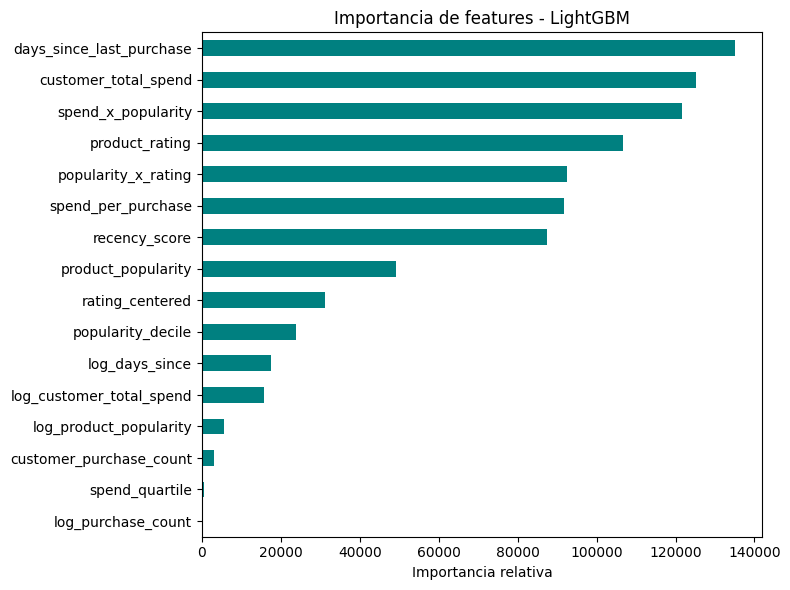

In [17]:
importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title(f"Importancia de features - {mejor_nombre}")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

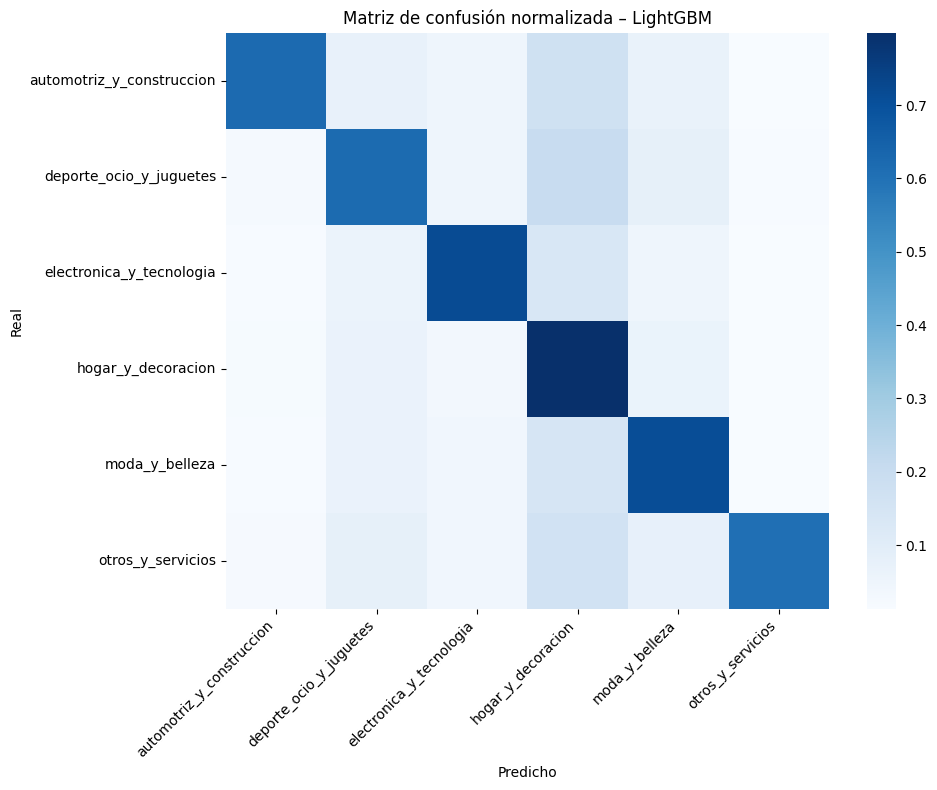

In [18]:
cm = confusion_matrix(y_test, mejor_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Matriz de confusión normalizada – {mejor_nombre}")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6.5 Ejemplo de predicción con un caso real

Para demostrar el funcionamiento del modelo final, se realiza una predicción sobre un caso individual del conjunto de prueba.

Esto permite comparar la categoría real del cliente con la categoría predicha por el modelo seleccionado.

In [19]:
# Buscamos un caso donde el modelo acierta para la demo
idx_demo = None

for idx in range(len(y_test)):
    real = le.inverse_transform([y_test[idx]])[0]
    pred = le.inverse_transform(mejor_modelo.predict(X_test.iloc[[idx]]))[0]
    
    if real == pred:
        idx_demo = idx
        break

if idx_demo is None:
    raise ValueError("No se encontró ningún caso correctamente predicho en el conjunto de prueba.")

cliente_ejemplo = X_test.iloc[[idx_demo]]
categoria_real = le.inverse_transform([y_test[idx_demo]])[0]
categoria_predicha = le.inverse_transform(mejor_modelo.predict(cliente_ejemplo))[0]

print("===== EJEMPLO DE PREDICCIÓN =====")
print(f"Índice usado: {idx_demo}")
print(f"Categoría REAL:     {categoria_real}")
print(f"Categoría PREDICHA: {categoria_predicha}")
print("✓ Predicción correcta" if categoria_real == categoria_predicha else "✗ Predicción incorrecta")

cliente_ejemplo

===== EJEMPLO DE PREDICCIÓN =====
Índice usado: 0
Categoría REAL:     electronica_y_tecnologia
Categoría PREDICHA: electronica_y_tecnologia
✓ Predicción correcta


,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase,log_customer_total_spend,log_product_popularity,log_purchase_count,log_days_since,spend_per_purchase,recency_score,popularity_x_rating,spend_x_popularity,rating_centered,spend_quartile,popularity_decile
76014,1,28,3.7,238.76,521,5.479638,3.367296,0.693147,6.257668,119.38,0.001916,103.6,6685.28,-0.33455,2,7


# 7. Conclusiones

## Síntesis de la comparación

- La reformulación del problema desde 73 categorías originales hacia 6 macro-categorías permitió transformar un escenario altamente desbalanceado y complejo en un problema multi-clase más estable y modelable.

- La incorporación de feature engineering avanzado (log-transforms, ratios, interacciones y variables derivadas) mejoró significativamente la capacidad predictiva respecto al enfoque inicial basado en variables simples.

- LightGBM obtuvo el mejor desempeño global con:
  - Accuracy ≈ 0.70
  - F1 macro ≈ 0.69
  - F1 weighted ≈ 0.70

- XGBoost mostró un rendimiento competitivo, aunque con mayor costo computacional y sin superar al modelo final.

- Random Forest aportó interpretabilidad y robustez, pero quedó claramente por debajo de los modelos boosting.

- El baseline DummyClassifier alcanzó un F1 weighted ≈ 0.12, lo que confirma que la mejora lograda por los modelos entrenados responde a aprendizaje real y no a efectos del desbalance.

---

## Aportes del feature engineering

- Variables de comportamiento histórico como `days_since_last_purchase` y `customer_total_spend` fueron las señales más relevantes para la clasificación.

- Las transformaciones logarítmicas ayudaron a reducir la asimetría de variables con cola larga.

- Las interacciones como `spend_x_popularity` y `popularity_x_rating` capturaron relaciones no lineales entre cliente y producto.

- La combinación de señales temporales, monetarias y de popularidad fortaleció la capacidad de generalización del modelo.

---

## Limitaciones

- La agrupación en macro-categorías simplifica el problema, pero reduce granularidad frente a recomendaciones a nivel producto.

- La categoría `otros_y_servicios` agrupa comportamientos heterogéneos, lo que limita separabilidad entre clases.

- El esquema actual utiliza un split estratificado tradicional y no validación temporal, por lo que futuras iteraciones deberían evaluar robustez en escenarios de drift temporal.

- Variables adicionales como ubicación geográfica, método de pago o embeddings de producto podrían incrementar desempeño.

---

## Aplicación dentro del sistema de recomendación

- Este modelo no reemplaza completamente un motor de recomendación personalizado item-to-item.

- Su principal aporte es funcionar como capa estratégica complementaria para:

  - predicción de intención de compra por categoría;
  - priorización de macro-categorías relevantes;
  - mitigación del problema de cold start;
  - soporte a una arquitectura híbrida junto con Collaborative Filtering / ALS.

- Desde la perspectiva de negocio, el modelo constituye una base sólida, escalable y desplegable para enriquecer el sistema de recomendación del e-commerce.

## Próximos pasos

- Aplicar Optuna para una optimización automatizada más exhaustiva sobre LightGBM.

- Incorporar nuevas variables explicativas, como ciudad del cliente, método de pago, frecuencia temporal de compra y atributos adicionales del producto.

- Evaluar validación temporal para medir robustez del modelo frente a cambios en comportamiento de compra.

- Integrar este clasificador como componente estratégico dentro del sistema de recomendación híbrido, complementando técnicas de Collaborative Filtering / ALS para recomendaciones personalizadas a nivel producto.

- Desplegar el modelo seleccionado mediante una aplicación interactiva (Streamlit/API) que permita realizar predicciones en tiempo real.